# Predicting Water Quality with K-Nearest Neighbors

K - Nearest Neighbors (K-NN) falls under the umbrella of Statistical Machine Learning as a non-parametric model

To prepare the data for K-NN algorithm, we have to meet four criteria,  
$\blacksquare$ Numeric Variables $\rightarrow$ All variables must be numeric, since the algorithm accepts only numeric inputs.  
$\blacksquare$ Address Missing Data $\rightarrow$ Missing data will mean that the distance between samples can't be calculated. Missing values could be excluded or imputed.  
$\blacksquare$ Rescale Data $\rightarrow$ Normalize/standardize all features before fitting K-NN model so that variables of large scale do not dominate the distance metric.  
$\blacksquare$ Reduce Dimensionality $\rightarrow$ K-NN can benefit from feature selection that reduces the dimensionality of the input feature space.

In [1]:
# Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from ipywidgets import interact
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
import math
from collections import Counter

In [2]:
df = pd.read_csv(r"D:\git things\Machine-Vision-Projects\Datasets\water-quality\waterQuality.csv")

### Exploratory Data Analysis

In [3]:
df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
df.shape

(7999, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

### Address Missing Values

In [6]:
# Drop missing values, Here we are removing all rows where ammonia has invalid text values (#NUM!).
df['ammonia'].value_counts()['#NUM!']
df = df[df['ammonia'].str.contains('#NUM!') == False]

### Numeric Variables

In [7]:
# Convert "ammonia" & "is_safe" columns to numeric data type
df['ammonia'] = pd.to_numeric(df['ammonia'])
df['is_safe'] = pd.to_numeric(df['is_safe'])

In [8]:
# Statistic metrics for continuous variables without scientific notation
df.describe().apply(lambda s: s.apply(lambda x: format(x, 'f')))

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
count,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,...,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000
mean,0.666396,14.278212,0.161477,1.567928,0.042803,2.177589,0.247300,0.805940,0.771646,0.319714,...,0.099431,9.819250,1.329846,0.005193,16.465266,2.920106,0.049684,0.147811,0.044672,0.114057
std,1.265323,8.878930,0.252632,1.216227,0.036049,2.567210,0.270663,0.653595,0.435423,0.329497,...,0.058169,5.541977,0.573271,0.002967,17.688827,2.322805,0.028773,0.143569,0.026906,0.317900
min,0.000000,-0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,6.577500,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.407500,0.000000,...,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000,0.000000
50%,0.070000,14.130000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,...,0.102000,9.930000,1.420000,0.005000,7.745000,2.410000,0.050000,0.080000,0.050000,0.000000
75%,0.280000,22.132500,0.100000,2.482500,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,...,0.151000,14.610000,1.760000,0.008000,29.487500,4.670000,0.070000,0.240000,0.070000,0.000000
max,5.050000,29.840000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,...,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000,1.000000


### Spliting to Train & Test Datasets

In [9]:
columns = df.columns
columns = [c for c in columns if c not in ['is_safe']]
y = df['is_safe'] #prior target variable
X = df[columns]  #prior features

# Preparation of train and test data for K-NN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5597, 20), (2399, 20), (5597,), (2399,))

### Distribution of the Target Variable

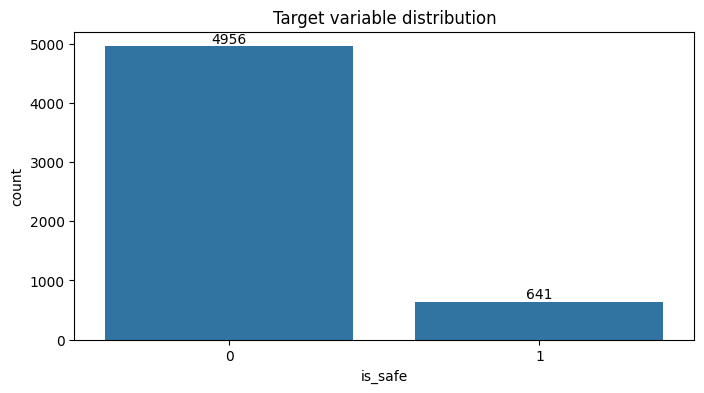

In [10]:
plt.figure(figsize=(8,4))
plt.title("Target variable distribution")
ax = sns.countplot(x=y_train)

# Add labels
for container in ax.containers:
    ax.bar_label(container)
plt.show()

As we can see in chart above, the target variable is highly imbalanced and we'll have to deal with it.  
We will use oversampling strategy using the RandomOverSampler class.  
Thus we will generate same numbers of rows for the value 1 of target variable "is_safe".  
Therefore we will get the same number of rows for both values of target variable.

### Oversampling
Oversampling is a technique used in machine learning to balance imbalanced datasets by increasing the representation of minority classes, often by duplicating samples or generating synthetic data.

In [11]:
ros = RandomOverSampler(sampling_strategy='minority')
X_train_os, y_train_os = ros.fit_resample(X_train, y_train)
print(f"Imbalanced target class: {Counter(y_train)}\n\nBalanced target class: {Counter(y_train_os)}\n")
print(X_train_os.shape[0] - X_train.shape[0], 'new random picked points')

Imbalanced target class: Counter({0: 4956, 1: 641})

Balanced target class: Counter({0: 4956, 1: 4956})

4315 new random picked points


Oversampling is done only to the train dataset.  
if the oversampling was done before spliting the dataset into train and test, then there will be a data leakage.  
That means the model will see the test data during training.  
Precision / Recall / F1-score will look too good but model will perform much worse for the unseen data.

### Balanced Distribution of the Traget Variable

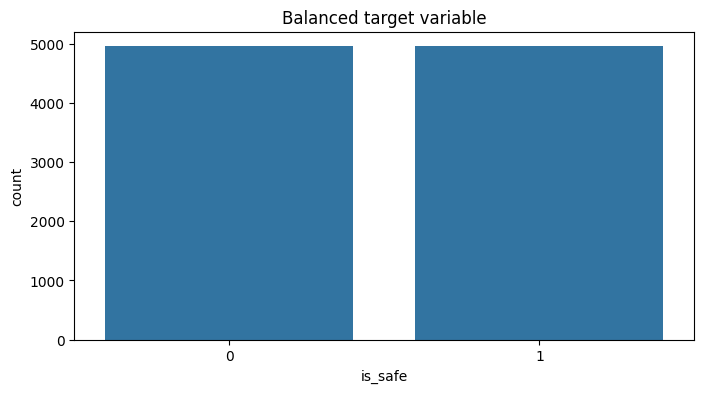

In [12]:
# Plot the balanced target variable
plt.figure(figsize=(8,4))
plt.title("Balanced target variable")
ax = sns.countplot(x=y_train_os)
plt.show()


We would also like to check, whether there are any statistically significant (<= -0.80, >= 0.80) correlations between all features.  
The highest correlations is between Viruses and Bateria (0.74).  
Nevertheless, it is not enough to consider these relations as statistically significant.

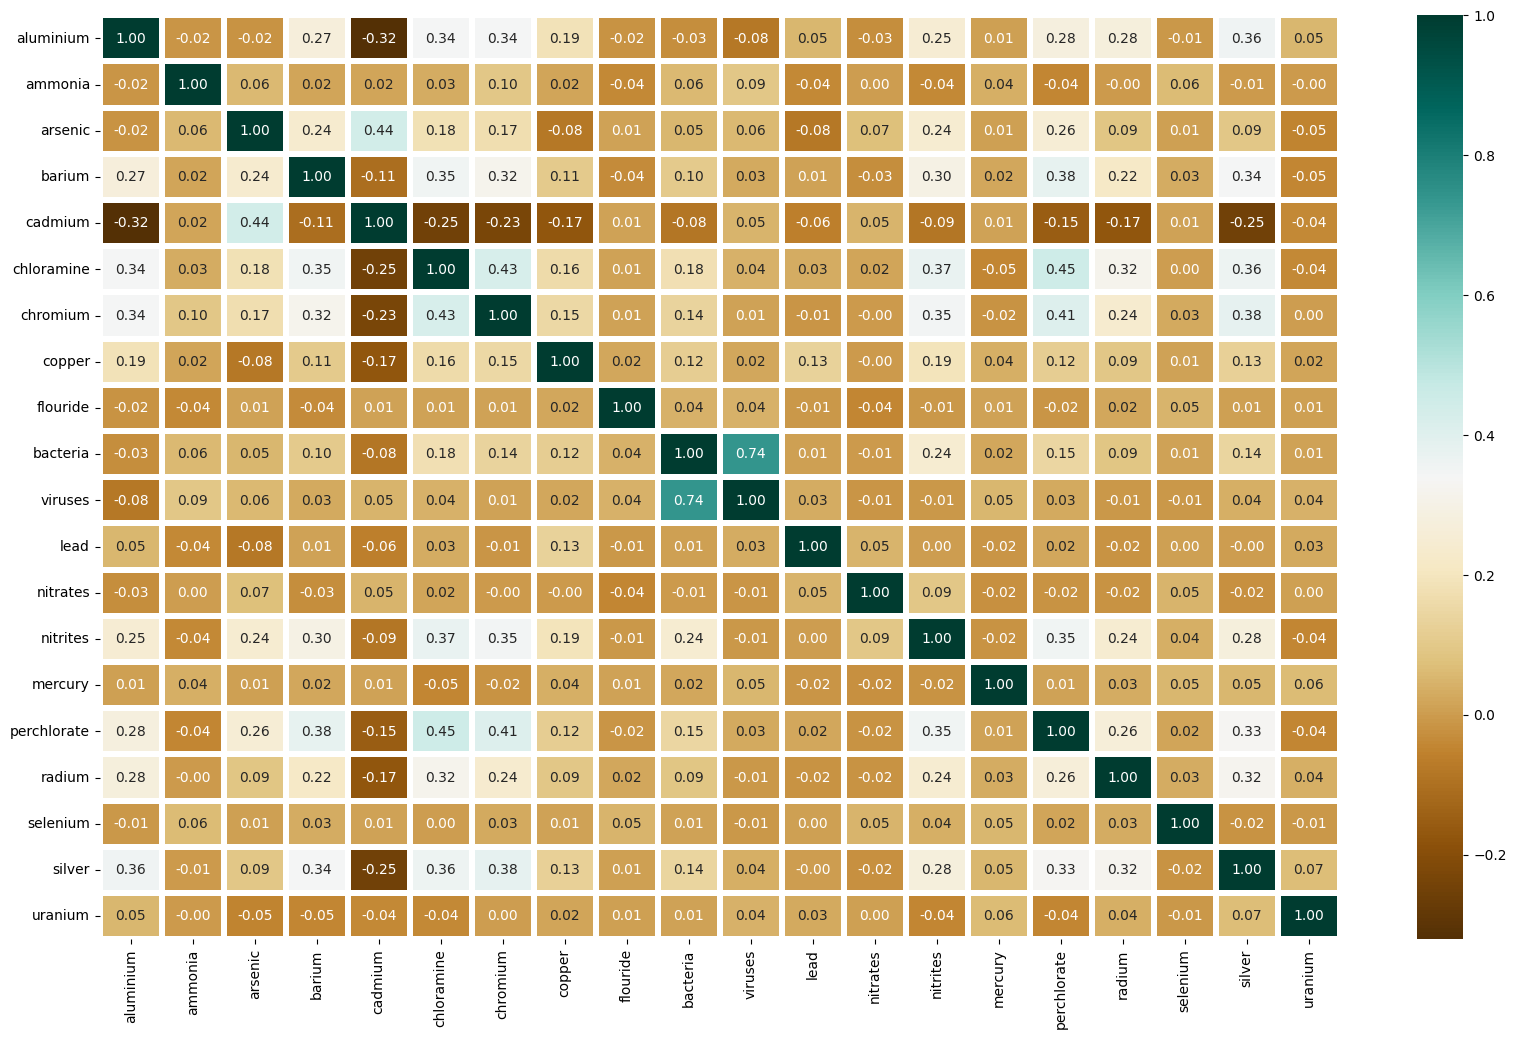

In [13]:
# Plotting correlation matrix to notice relationships or lack of it between variables
corr = X_train_os.corr()
plt.figure(figsize = (20, 12))
sns.heatmap(corr, xticklabels = corr.columns, yticklabels = corr.columns, linewidths = 4, annot = True, fmt = ".2f", cmap="BrBG")
plt.show()

### Rescale Data

This scales train data and also the test data using same parameters (mean and standard deviation) that calculated from training data
$$
z = \frac{x - \mu_{train}}{\sigma_{train}}
$$

In [14]:
sc = StandardScaler()
sc.fit(X_train_os)
X_train_os_std = sc.transform(X_train_os)
X_test_std = sc.transform(X_test)
print('After standardizing our features, the first 5 rows of our data now look like this:\n')
pd.DataFrame(X_train_os_std).head()

After standardizing our features, the first 5 rows of our data now look like this:



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.758043,1.216003,-0.141618,-0.738905,0.840717,-0.993491,-0.973942,-0.197104,0.323400,1.073693,1.033070,1.444288,1.181807,-0.921078,0.308586,-1.080208,0.079755,1.092675,-1.038025,0.280230
1,0.420122,-0.399148,-0.370007,1.700727,-0.860421,1.130402,1.396478,1.181629,-1.302199,-0.961056,-0.777105,-1.420501,-0.765613,0.223406,-1.349069,1.266936,1.881924,-0.290454,1.567319,-1.196059
2,2.383730,0.462723,-0.370007,-1.295600,-0.745090,0.963746,1.935210,-0.338111,0.462737,-0.251977,-0.760649,0.374306,-0.061983,-0.125758,-0.686007,-0.683866,1.128132,-1.327801,-0.904417,1.018375
3,-0.725853,-1.310171,2.370660,0.759258,-0.312597,1.641997,0.426761,-1.293824,1.252314,1.012034,0.978217,-0.091653,0.869083,0.242804,-0.354476,1.207546,-0.145516,0.746893,0.899282,-0.457915
4,2.081141,1.768103,1.685493,0.808378,-0.024269,0.905610,1.145070,-1.152817,-0.117834,-0.961056,-0.755164,-1.506790,1.018338,-0.145156,0.640117,1.414807,1.353403,1.784240,0.832478,0.649302


### Reduce Dimensionality

SelectKBest $\rightarrow$ Selects the top K most important features.  
f_classif $\rightarrow$ This uses the ANOVA F-test scoring function to measure how strongly each feature is related to the target.

In [15]:
# Find best scored 10 features
select_feature = SelectKBest(f_classif, k=10).fit(X_train_os_std, y_train_os)
feature_scores = pd.DataFrame({'Feature': X_train.columns, 'Score': select_feature.scores_})

# Sort by score (highest first)
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)

X_train_2 = select_feature.transform(X_train_os_std)
X_test_2 = select_feature.transform(X_test_std)

        Feature        Score
4       cadmium  2523.373925
0     aluminium  2517.567472
5    chloramine   867.184545
6      chromium   723.324146
2       arsenic   631.181768
10      viruses   247.974834
18       silver   242.318341
3        barium   214.189081
15  perchlorate   172.998557
12     nitrates   163.643162
16       radium   154.786795
19      uranium   112.710804
13     nitrites    57.846056
17     selenium    41.719303
14      mercury    37.677607
7        copper    22.006919
9      bacteria    16.857339
1       ammonia     5.568299
11         lead     4.096504
8      flouride     1.288199


### K-Nearest Neighbors (KNN) Classifier

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm used for classification.

Given a training dataset:
$$
\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}
$$
where $x_i \in \mathbb{R}^d$ and $y_i \in \{1, 2, \dots, C\}$,

For a new input point $x$, KNN computes the distance between $x$ and all training samples.

A commonly used distance metric is the Euclidean distance:
$$
d(x, x_i) = \sqrt{\sum_{j=1}^{d} (x_j - x_{ij})^2}
$$

The algorithm selects the $k$ nearest neighbors:
$$
\mathcal{N}_k(x)
$$

The predicted class is determined by majority voting:


[[1776  352]
 [  88  183]]


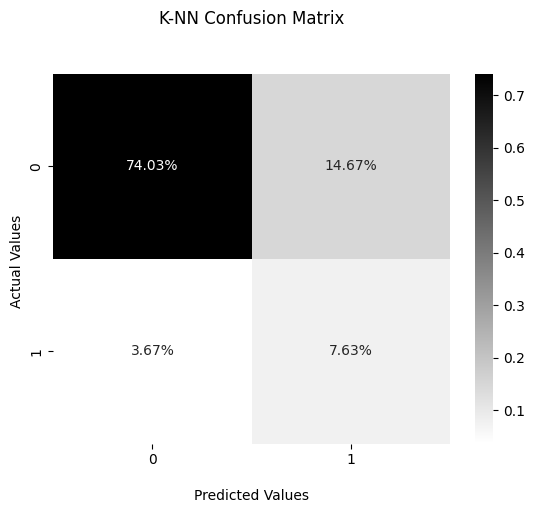

In [16]:
# neighbor count is 5 by default
knnc = KNeighborsClassifier()   
knnc = knnc.fit(X_train_2,y_train_os)
y_pred_knnc = knnc.predict(X_test_2)
cf_matrix_knnc = confusion_matrix(y_test, y_pred_knnc)
print(cf_matrix_knnc)

ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary')
ax.set_title('K-NN Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['0','1'])
ax.yaxis.set_ticklabels(['0','1'])

## Display the visualization of the Confusion Matrix.
plt.show()

### Confusion Matrix
A confusion matrix is a table used to evaluate the performance of a classification model. It compares the actual target values with the predicted values and summarizes the results into four categories:  
  
$\bullet$ True Positives $(TP)$: Correctly predicted positive instances  
$\bullet$ True Negatives $(TN)$: Correctly predicted negative instances  
$\bullet$ False Positives $(FP)$: Incorrectly predicted as positive (Type I error)  
$\bullet$ False Negatives $(FN)$: Incorrectly predicted as negative (Type II error)  

$\bold{Precision}$,  
Precision measures the accuracy of positive predictions. It indicates how many of the instances predicted as positive are actually positive.
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
$\bold{Recall}$,  
Recall (also known as sensitivity) measures the ability of the model to correctly identify all positive instances.
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
$\bold{F1-Score}$,  
F1-Score is the harmonic mean of precision and recall. It provides a balance between the two metrics, especially when there is an uneven class distribution.
$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}
$$


In [17]:
#evaluation of K-NN: metrics pivot chart
print(classification_report(y_test, y_pred_knnc))

print('Accuracy Score : ' + str(round(accuracy_score(y_test,y_pred_knnc),3)))
print('Precision Score : ' + str(round(precision_score(y_test,y_pred_knnc,pos_label=0),3)))
print('Recall Score : ' + str(round(recall_score(y_test,y_pred_knnc,pos_label=0),3)))
print('F-Score : ' + str(round(f1_score(y_test,y_pred_knnc,pos_label=0),3)))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89      2128
           1       0.34      0.68      0.45       271

    accuracy                           0.82      2399
   macro avg       0.65      0.75      0.67      2399
weighted avg       0.88      0.82      0.84      2399

Accuracy Score : 0.817
Precision Score : 0.953
Recall Score : 0.835
F-Score : 0.89


Considering about Precision and Recall is essential since our dataset is a biased dataset.  
According to Precision (0.34), Recall (0.68) and F1-Score (0.45), the model is not performing well for the new data.  
We may have to move to a different model to get a better Precision, Recall and F1-Score.

In [18]:
# create numpy array for future K value
neighbors = np.arange(1, 40)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop over different values of k
for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_2, y_train_os)
    train_accuracy[i] = knn.score(X_train_2, y_train_os)
    test_accuracy[i] = knn.score(X_test_2, y_test)

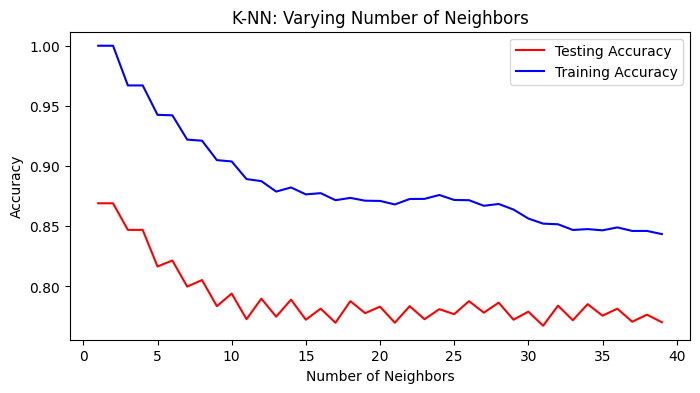

In [19]:
plt.figure(figsize=(8,4)) 
plt.title(label='K-NN: Varying Number of Neighbors')
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy', color="red")
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy', color = "blue")
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()